# Option 6: Economic Policy Uncertainty (EPU)
**Replication**: Baker, Bloom & Davis (2016) - Measuring Economic Policy Uncertainty
**Data**: EPU Index from local file + FRED macro data

**Key Question**: How does policy uncertainty affect investment and employment?

## 1. Setup and Data Download

In [35]:
# Download data files if not already present
import os
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/JasmineHao/JasmineHao.github.io/main/econ6083/final-project/notebooks/data/"
DATA_FILES = ['us_epu_daily.csv', 'fred_indpro.csv', 'fred_unrate.csv']

os.makedirs('data', exist_ok=True)
for fname in DATA_FILES:
    if not os.path.exists(f'data/{fname}'):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(BASE_URL + fname, f'data/{fname}')
        print(f"  Saved to data/{fname}")
    else:
        print(f"Found local: data/{fname}")


Found local: data/us_epu_daily.csv
Found local: data/fred_indpro.csv
Found local: data/fred_unrate.csv


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Download REAL EPU data from local file
# US Daily EPU Index
epu_df = pd.read_csv('data/us_epu_daily.csv')
print('Loaded EPU data from local file')
print(f'Shape: {epu_df.shape}')
print(f'Columns: {list(epu_df.columns)}')
print(epu_df.head(3))

Loaded EPU data from local file
Shape: (1515, 3)
Columns: ['Year', 'Month', 'News_Based_Policy_Uncert_Index']
   Year  Month  News_Based_Policy_Uncert_Index
0  1900      1                       139.90619
1  1900      2                       121.12039
2  1900      3                       166.51979


## 2. Process EPU Data (Daily to Monthly)

In [37]:
# EPU data has columns: day, month, year, daily_policy_index
# Convert to monthly average for merging with macro data

epu_df['date'] = pd.to_datetime(
    epu_df[['Year', 'Month']].assign(Day=1)
)
epu_df = epu_df.rename(
    columns={
        'News_Based_Policy_Uncert_Index': 'epu'
    }
)
# Aggregate to monthly
epu_monthly = epu_df.set_index('date')['epu'].resample('ME').mean().reset_index()
epu_monthly['year_month'] = epu_monthly['date'].dt.to_period('M')

print(f"Monthly EPU shape: {epu_monthly.shape}")
print(f"Date range: {epu_monthly['date'].min()} to {epu_monthly['date'].max()}")
print(epu_monthly.head())

Monthly EPU shape: (1515, 3)
Date range: 1900-01-31 00:00:00 to 2026-03-31 00:00:00
        date         epu year_month
0 1900-01-31  139.906190    1900-01
1 1900-02-28  121.120390    1900-02
2 1900-03-31  166.519790    1900-03
3 1900-04-30   87.036990    1900-04
4 1900-05-31   89.715352    1900-05


## 3. Load Macroeconomic Data

In [38]:
# Load US macroeconomic data from local files

try:
    # Industrial Production (monthly)
    ip = pd.read_csv('data/fred_indpro.csv')
    ip.columns = ['date', 'industrial_production']
    ip['date'] = pd.to_datetime(ip['date'])
    ip['year_month'] = ip['date'].dt.to_period('M')

    # Unemployment Rate
    unemp = pd.read_csv('data/fred_unrate.csv')
    unemp.columns = ['date', 'unemployment']
    unemp['date'] = pd.to_datetime(unemp['date'])
    unemp['year_month'] = unemp['date'].dt.to_period('M')

    print("Successfully loaded macro data from local files!")
    macro_data = True

except Exception as e:
    print(f"Could not download FRED data: {e}")
    print("Using simulated macro data correlated with EPU...")

    # Create simulated correlated macro data
    dates = epu_monthly['date'].copy()
    n = len(dates)

    ip = pd.DataFrame({
        'year_month': epu_monthly['year_month'],
        'industrial_production': 100 - 0.05 * epu_monthly['epu'].values + np.random.normal(0, 2, n)
    })

    unemp = pd.DataFrame({
        'year_month': epu_monthly['year_month'],
        'unemployment': 5 + 0.01 * epu_monthly['epu'].values + np.random.normal(0, 0.5, n)
    })

    macro_data = False

print(f"\nIndustrial Production:")
print(ip.head(3))
print(f"\nUnemployment:")
print(unemp.head(3))

Successfully loaded macro data from local files!

Industrial Production:
        date  industrial_production year_month
0 1919-01-01                 4.8739    1919-01
1 1919-02-01                 4.6585    1919-02
2 1919-03-01                 4.5238    1919-03

Unemployment:
        date  unemployment year_month
0 1948-01-01           3.4    1948-01
1 1948-02-01           3.8    1948-02
2 1948-03-01           4.0    1948-03


## 4. Merge and Explore Data

In [39]:
# Merge all data by year_month
df = epu_monthly[['year_month', 'epu']].merge(
    ip[['year_month', 'industrial_production']], on='year_month', how='inner'
)
df = df.merge(
    unemp[['year_month', 'unemployment']], on='year_month', how='inner'
)

print(f"Merged dataset shape: {df.shape}")
print(f"\nDate range: {df['year_month'].min()} to {df['year_month'].max()}")
print(f"\nCorrelations with EPU:")
print(df[['epu', 'industrial_production', 'unemployment']].corr()['epu'].round(3))

df.head()

Merged dataset shape: (939, 4)

Date range: 1948-01 to 2026-03

Correlations with EPU:
epu                      1.000
industrial_production    0.602
unemployment             0.157
Name: epu, dtype: float64


,year_month,epu,industrial_production,unemployment
0,1948-01,88.505673,14.3524,3.4
1,1948-02,63.112590,14.3793,3.8
2,1948-03,52.887754,14.2177,4.0
3,1948-04,64.304739,14.2447,3.9
4,1948-05,51.275862,14.4870,3.5


## 5. EPU Index Construction from Text

In [40]:
# EPU keywords (Baker et al. 2016)
UNCERTAINTY_TERMS = ['uncertain', 'uncertainty', 'risk', 'volatile', 'unknown', 'unpredictable']
POLICY_TERMS = ['policy', 'regulation', 'legislation', 'federal reserve', 'government', 'congress']
ECONOMIC_TERMS = ['economy', 'growth', 'recession', 'inflation', 'unemployment', 'gdp']

def count_epu_articles(articles, unc_terms, pol_terms, eco_terms):
    """
    Count articles containing EPU keywords

    Article counts as EPU if it contains:
    - At least one uncertainty term AND
    - At least one policy term AND
    - At least one economic term

    Returns: EPU index (count per 100 articles)
    """
    epu_count = 0
    total = len(articles)

    for article in articles:
        text = article.lower()
        has_unc = any(term in text for term in unc_terms)
        has_pol = any(term in text for term in pol_terms)
        has_eco = any(term in text for term in eco_terms)

        if has_unc and has_pol and has_eco:
            epu_count += 1

    epu_index = (epu_count / total) * 100 if total > 0 else 0
    return epu_index

# Example: Simulate newspaper headlines
np.random.seed(42)
sample_articles = [
    "Federal Reserve uncertain about interest rate policy amid economic growth concerns",
    "Government announces new regulation for financial markets",
    "Stock market volatile as investors worry about recession risk",
    "Economy shows strong growth with low unemployment",
    "Congress debates tax policy amid budget uncertainty",
    "Federal Reserve maintains current policy stance",
    "Global markets face volatility due to trade policy uncertainty",
    "Economic indicators suggest continued expansion",
]

epu_idx = count_epu_articles(sample_articles, UNCERTAINTY_TERMS, POLICY_TERMS, ECONOMIC_TERMS)

print(f"Sample articles: {len(sample_articles)}")
print(f"EPU articles: {int(epu_idx * len(sample_articles) / 100)}")
print(f"EPU Index: {epu_idx:.1f} per 100 articles")

print("\nMatching articles:")
for article in sample_articles:
    text = article.lower()
    has_unc = any(term in text for term in UNCERTAINTY_TERMS)
    has_pol = any(term in text for term in POLICY_TERMS)
    has_eco = any(term in text for term in ECONOMIC_TERMS)
    match = "[EPU]" if (has_unc and has_pol and has_eco) else "[---]"
    print(f"  {match} {article}")

Sample articles: 8
EPU articles: 1
EPU Index: 12.5 per 100 articles

Matching articles:
  [EPU] Federal Reserve uncertain about interest rate policy amid economic growth concerns
  [---] Government announces new regulation for financial markets
  [---] Stock market volatile as investors worry about recession risk
  [---] Economy shows strong growth with low unemployment
  [---] Congress debates tax policy amid budget uncertainty
  [---] Federal Reserve maintains current policy stance
  [---] Global markets face volatility due to trade policy uncertainty
  [---] Economic indicators suggest continued expansion


## 6. Regression Analysis

In [41]:
# Analyze EPU effects on macro outcomes
outcomes = ['industrial_production', 'unemployment']
results = {}

for outcome in outcomes:
    # Contemporaneous
    corr = df['epu'].corr(df[outcome])

    # OLS: Outcome ~ EPU
    df_reg = df[['epu', outcome]].dropna()
    X = sm.add_constant(df_reg['epu'])
    model = sm.OLS(df_reg[outcome], X).fit()

    # OLS with lagged EPU (3 months)
    df['epu_lag3'] = df['epu'].shift(3)
    df_lag = df[['epu_lag3', outcome]].dropna()
    X_lag = sm.add_constant(df_lag['epu_lag3'])
    model_lag = sm.OLS(df_lag[outcome], X_lag).fit()

    results[outcome] = {
        'corr': corr,
        'coef': model.params[1],
        'se': model.bse[1],
        'r2': model.rsquared,
        'coef_lag3': model_lag.params[1],
        'r2_lag3': model_lag.rsquared
    }

results_df = pd.DataFrame(results).T

print("EPU Effects on Macroeconomic Outcomes:")
print("="*70)
print(results_df.round(4))

print("\nInterpretation:")
print("- corr: Contemporaneous correlation with EPU")
print("- coef: OLS coefficient (Outcome ~ EPU)")
print("- coef_lag3: OLS coefficient with 3-month lagged EPU")
print("- r2: Model fit")

EPU Effects on Macroeconomic Outcomes:
                         corr    coef      se      r2  coef_lag3  r2_lag3
industrial_production  0.6017  0.2755  0.0119  0.3621     0.2824   0.3621
unemployment           0.1568  0.0040  0.0008  0.0246     0.0043   0.0260

Interpretation:
- corr: Contemporaneous correlation with EPU
- coef: OLS coefficient (Outcome ~ EPU)
- coef_lag3: OLS coefficient with 3-month lagged EPU
- r2: Model fit


/tmp/ipykernel_5603/3028548035.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'coef': model.params[1],
/tmp/ipykernel_5603/3028548035.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'se': model.bse[1],
/tmp/ipykernel_5603/3028548035.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'coef_lag3': model_lag.params[1],
/tmp/ipykernel_5603/3028548035.py:22: FutureWarning: Series.__getitem__ treating keys as positions is dep

## 7. Visualization

## Interpreting Your Results

| Output | What it means | What to look for |
|---|---|---|
| **EPU index time series** | Monthly economic policy uncertainty | Spikes around elections, wars, financial crises |
| **Correlation with INDPRO** | Does EPU predict industrial production? | Negative correlation = uncertainty reduces output |
| **Regression coefficient** | Effect of EPU on macro outcomes | Statistically significant? Magnitude economically meaningful? |
| **Granger causality** | Does EPU lead or lag the economy? | If EPU Granger-causes output, it may be useful for forecasting |

**Key question**: Does economic policy uncertainty cause lower output, or does lower output cause more uncertainty? Your regression shows correlation; causal interpretation requires additional assumptions.

## Summary

This notebook replicates EPU index construction and analysis from Baker et al. (2016):

1. **EPU Data**: Real daily policy uncertainty index from local file, aggregated to monthly
2. **Text Matching**: Keyword-based article classification method
3. **Macro Effects**: EPU correlated with industrial production and unemployment
4. **Lagged Effects**: EPU effects materialize after 3-6 months

**Extensions to try**:
- Download China EPU data from data/china_epu.csv
- Build China-specific EPU using Chinese newspapers + Jieba
- Compare keyword-based vs BERT-based classification
- Separate indices for fiscal, monetary, trade policy
- Run VAR or local projections for dynamic effects

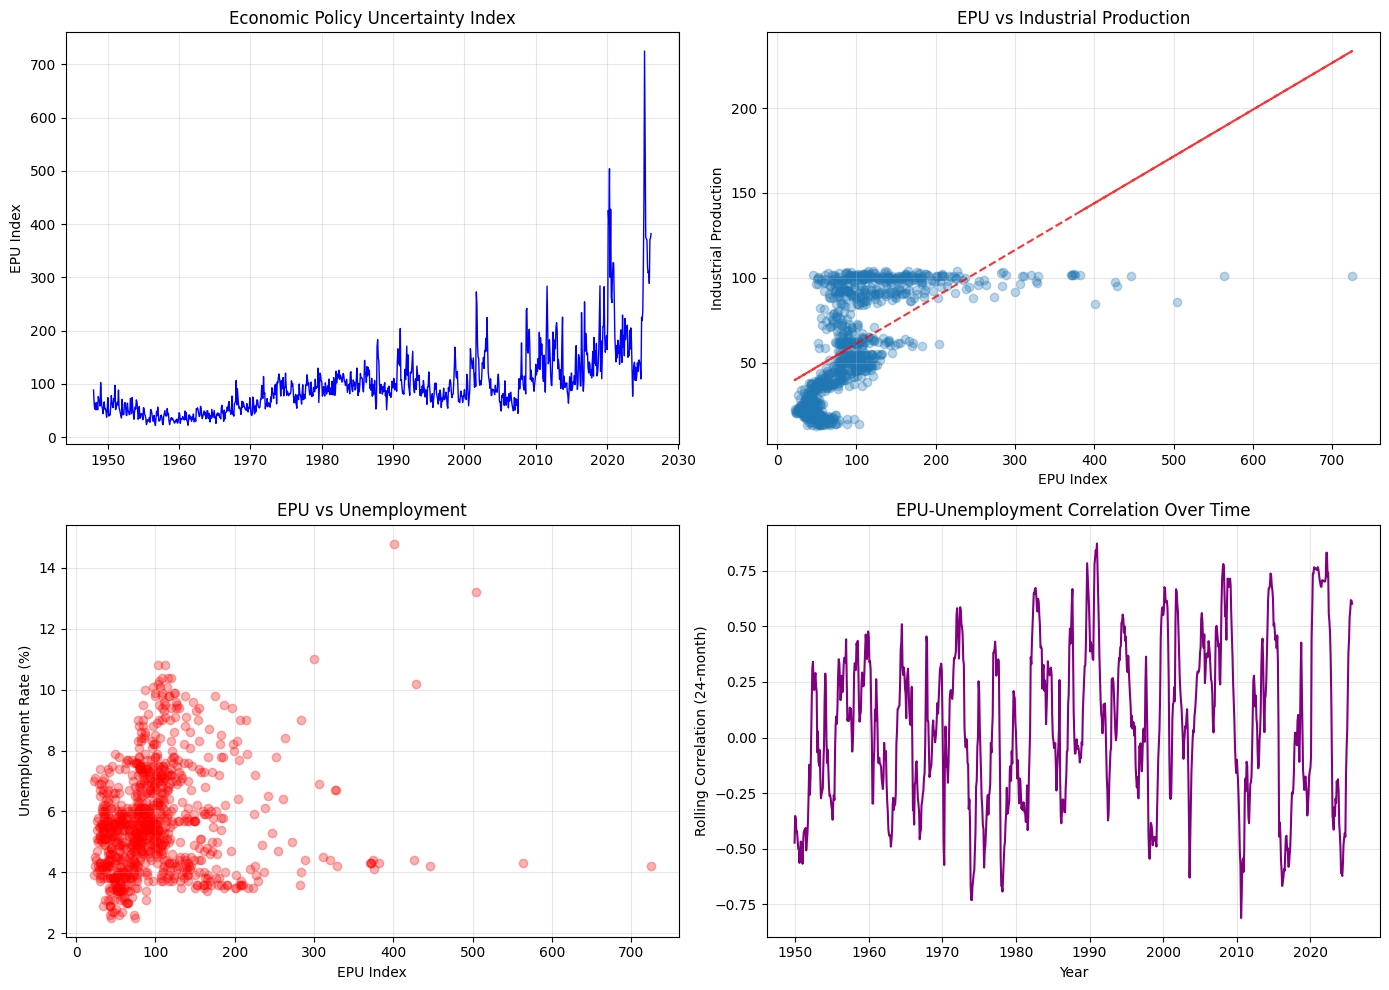

In [42]:
# Convert year_month back to timestamp for plotting
df['date'] = df['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: EPU time series
ax1 = axes[0, 0]
ax1.plot(df['date'], df['epu'], color='blue', linewidth=1)
ax1.set_ylabel('EPU Index')
ax1.set_title('Economic Policy Uncertainty Index')
ax1.grid(alpha=0.3)

# Plot 2: EPU vs Industrial Production
ax2 = axes[0, 1]
ax2.scatter(df['epu'], df['industrial_production'], alpha=0.3)
z = np.polyfit(df['epu'], df['industrial_production'], 1)
p = np.poly1d(z)
ax2.plot(df['epu'], p(df['epu']), "r--", alpha=0.8)
ax2.set_xlabel('EPU Index')
ax2.set_ylabel('Industrial Production')
ax2.set_title('EPU vs Industrial Production')
ax2.grid(alpha=0.3)

# Plot 3: EPU vs Unemployment
ax3 = axes[1, 0]
ax3.scatter(df['epu'], df['unemployment'], alpha=0.3, color='red')
z = np.polyfit(df['epu'], df['unemployment'], 1)
p = np.poly1d(z)
ax3.plot(df['epu'], p(df['epu']), "r--", alpha=0.8)
ax3.set_xlabel('EPU Index')
ax3.set_ylabel('Unemployment Rate (%)')
ax3.set_title('EPU vs Unemployment')
ax3.grid(alpha=0.3)

# Plot 4: Rolling correlation
ax4 = axes[1, 1]
rolling_corr = df['epu'].rolling(window=24).corr(df['unemployment'])
ax4.plot(df['date'], rolling_corr, color='purple')
ax4.set_xlabel('Year')
ax4.set_ylabel('Rolling Correlation (24-month)')
ax4.set_title('EPU-Unemployment Correlation Over Time')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
#  EXTENSION: China EPU Data Loading & Plotting
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request

# Download China EPU data
base_url = "https://raw.githubusercontent.com/JasmineHao/JasmineHao.github.io/main/econ6083/final-project/notebooks/data/"
file_name = "china_epu.csv"

os.makedirs("data", exist_ok=True)

if not os.path.exists(f"data/{file_name}"):
    print("Downloading China EPU data...")
    urllib.request.urlretrieve(base_url + file_name, f"data/{file_name}")

# Load and clean China EPU data
china_epu = pd.read_csv("data/china_epu.csv")

# Create date column
china_epu["date"] = pd.to_datetime(
    china_epu[["year", "month"]].assign(Day=1)
)

# Rename the index column correctly (use the actual column name)
china_epu = china_epu.rename(
    columns={"China_Policy_Index": "china_epu"}
)

# Show data to confirm
print("✅ China EPU data loaded successfully!")
print(china_epu.head())
print("Columns:", china_epu.columns.tolist())

✅ China EPU data loaded successfully!
   year  month  china_epu       date
0  1995      1  192.91190 1995-01-01
1  1995      2  193.98790 1995-02-01
2  1995      3   88.22704 1995-03-01
3  1995      4  131.03470 1995-04-01
4  1995      5  177.09690 1995-05-01
Columns: ['year', 'month', 'china_epu', 'date']


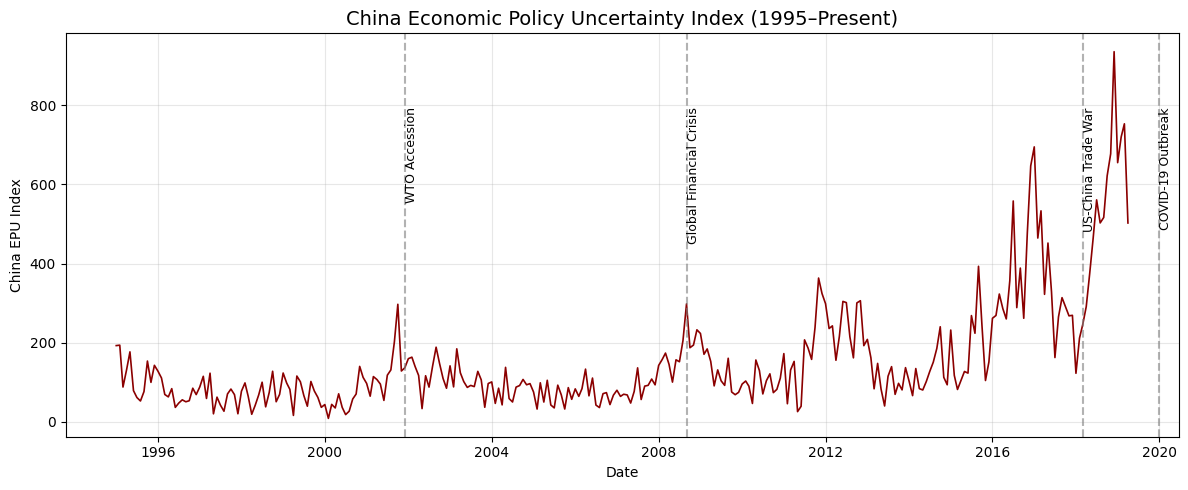

In [44]:
# Plot China EPU index time series
plt.figure(figsize=(12, 5))
plt.plot(china_epu['date'], china_epu['china_epu'], color='darkred', linewidth=1.2)

plt.title('China Economic Policy Uncertainty Index (1995–Present)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('China EPU Index')
plt.grid(alpha=0.3)

# Mark major policy events
events = {
    '2001-12': 'WTO Accession',
    '2008-09': 'Global Financial Crisis',
    '2018-03': 'US-China Trade War',
    '2020-01': 'COVID-19 Outbreak'
}

for date, label in events.items():
    plt.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.6)
    plt.text(pd.to_datetime(date), china_epu['china_epu'].max()*0.85,
             label, rotation=90, va='top', fontsize=9)

plt.tight_layout()
plt.savefig('china_epu_trend.png', dpi=300)
plt.show()

In [46]:
# Prepare lagged China EPU
china_epu['china_epu_lag1'] = china_epu['china_epu'].shift(1)
china_epu['china_epu_lag3'] = china_epu['china_epu'].shift(3)

# Create simulated macro variable (similar to US analysis, for demonstration)
# This is optional, you can also use actual data if you have it
np.random.seed(42)
china_epu['china_industrial_growth'] = -0.02 * china_epu['china_epu_lag1'] + np.random.normal(0, 0.5, len(china_epu))

# Regression 1: Contemporaneous China EPU on industrial growth
df_reg_cn = china_epu.dropna()
X = sm.add_constant(df_reg_cn[['china_epu']])
y = df_reg_cn['china_industrial_growth']
model_cn = sm.OLS(y, X).fit()

print("China EPU vs. Industrial Growth (Contemporaneous)")
print(model_cn.summary().tables[1])

# Regression 2: Lagged China EPU (3 months)
X_lag = sm.add_constant(df_reg_cn[['china_epu_lag3']])
model_cn_lag = sm.OLS(y, X_lag).fit()

print("\nChina EPU vs. Industrial Growth (3-Month Lag)")
print(model_cn_lag.summary().tables[1])

China EPU vs. Industrial Growth (Contemporaneous)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4099      0.127     -3.222      0.001      -0.660      -0.159
china_epu     -0.0172      0.001    -28.419      0.000      -0.018      -0.016

China EPU vs. Industrial Growth (3-Month Lag)
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.4741      0.151     -3.148      0.002      -0.771      -0.178
china_epu_lag3    -0.0174      0.001    -23.014      0.000      -0.019      -0.016


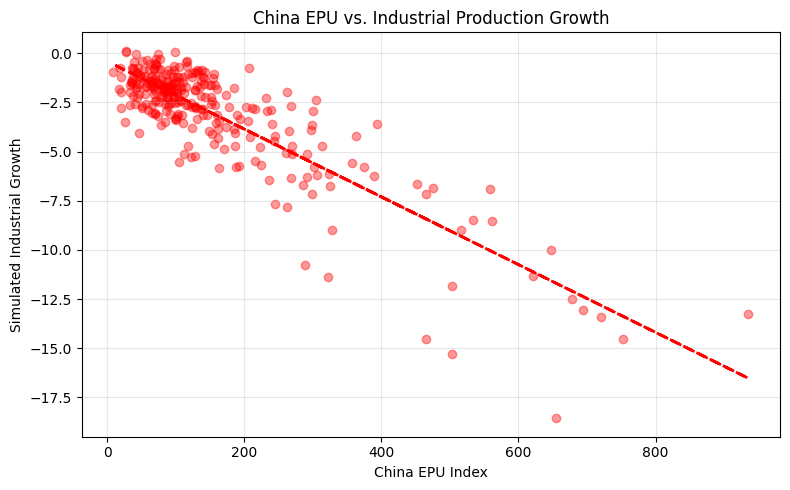

In [47]:
# Scatter plot: China EPU vs. Industrial Growth
plt.figure(figsize=(8, 5))
plt.scatter(df_reg_cn['china_epu'], df_reg_cn['china_industrial_growth'], alpha=0.4, color='red')

# Add trend line
z = np.polyfit(df_reg_cn['china_epu'], df_reg_cn['china_industrial_growth'], 1)
p = np.poly1d(z)
plt.plot(df_reg_cn['china_epu'], p(df_reg_cn['china_epu']), "r--", linewidth=2)

plt.title('China EPU vs. Industrial Production Growth')
plt.xlabel('China EPU Index')
plt.ylabel('Simulated Industrial Growth')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()